# 01 – Exploring the Data
  762,091 used car listings from cars.com (April 2023). Goal: understand the data, find errors, and plan the cleaning.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("../data/cars.csv")

In [2]:
df.shape

(762091, 20)

In [3]:
df.head()

,manufacturer,model,year,mileage,engine,transmission,drivetrain,fuel_type,mpg,exterior_color,interior_color,accidents_or_damage,one_owner,personal_use_only,seller_name,seller_rating,driver_rating,driver_reviews_num,price_drop,price
0,Acura,ILX Hybrid 1.5L,2013,92945.0,"1.5L I-4 i-VTEC variable valve control, engine...",Automatic,Front-wheel Drive,Gasoline,39-38,Black,Parchment,0.0,0.0,0.0,Iconic Coach,NaN,4.4,12.0,300.0,13988.0
1,Acura,ILX Hybrid 1.5L,2013,47645.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Gray,Ebony,1.0,1.0,1.0,Kars Today,NaN,4.4,12.0,NaN,17995.0
2,Acura,ILX Hybrid 1.5L,2013,53422.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Bellanova White Pearl,Ebony,0.0,1.0,1.0,Weiss Toyota of South County,4.3,4.4,12.0,500.0,17000.0
3,Acura,ILX Hybrid 1.5L,2013,117598.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Polished Metal Metallic,NaN,0.0,1.0,1.0,Apple Tree Acura,NaN,4.4,12.0,675.0,14958.0
4,Acura,ILX Hybrid 1.5L,2013,114865.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,NaN,Ebony,1.0,0.0,1.0,Herb Connolly Chevrolet,3.7,4.4,12.0,300.0,14498.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 762091 entries, 0 to 762090
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   manufacturer         762091 non-null  str    
 1   model                762091 non-null  str    
 2   year                 762091 non-null  int64  
 3   mileage              761585 non-null  float64
 4   engine               747041 non-null  str    
 5   transmission         752187 non-null  str    
 6   drivetrain           740529 non-null  str    
 7   fuel_type            739164 non-null  str    
 8   mpg                  620020 non-null  str    
 9   exterior_color       753232 non-null  str    
 10  interior_color       705116 non-null  str    
 11  accidents_or_damage  737879 non-null  float64
 12  one_owner            730608 non-null  float64
 13  personal_use_only    737239 non-null  float64
 14  seller_name          753498 non-null  str    
 15  seller_rating        548118 

In [5]:
df.isna().sum().sort_values(ascending=False)

price_drop             351979
seller_rating          213973
mpg                    142071
interior_color          56975
driver_rating           31632
one_owner               31483
personal_use_only       24852
accidents_or_damage     24212
fuel_type               22927
drivetrain              21562
engine                  15050
transmission             9904
exterior_color           8859
seller_name              8593
mileage                   506
manufacturer                0
year                        0
model                       0
driver_reviews_num          0
price                       0
dtype: int64

In [6]:
df.describe()

,year,mileage,accidents_or_damage,one_owner,personal_use_only,seller_rating,driver_rating,driver_reviews_num,price_drop,price
count,762091.000000,7.615850e+05,737879.000000,730608.000000,737239.000000,548118.000000,730459.000000,762091.000000,410112.000000,7.620910e+05
mean,2017.791398,5.578169e+04,0.228616,0.561969,0.657212,4.158568,4.623523,89.550900,1007.467068,3.648898e+04
std,5.110532,4.355788e+04,0.419942,0.496145,0.474642,0.805741,0.276902,115.082266,1375.122208,1.984183e+06
min,1915.000000,0.000000e+00,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,100.000000,1.000000e+00
25%,2016.000000,2.328700e+04,0.000000,0.000000,0.000000,3.800000,4.500000,14.000000,380.000000,1.958300e+04
50%,2019.000000,4.559600e+04,0.000000,1.000000,1.000000,4.500000,4.700000,51.000000,642.000000,2.798900e+04
75%,2021.000000,7.836500e+04,0.000000,1.000000,1.000000,4.700000,4.800000,119.000000,1007.000000,3.948800e+04
max,2024.000000,1.119067e+06,1.000000,1.000000,1.000000,5.000000,5.000000,1025.000000,170995.000000,1.000000e+09


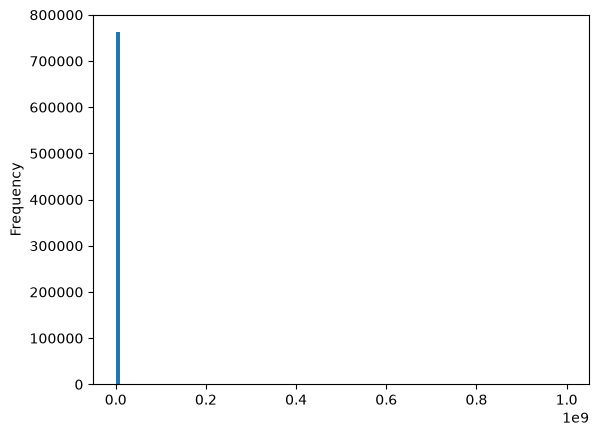

In [7]:
ax = df["price"].plot(kind="hist", bins = 100)

Since the histogram is barely readable, there must be some outliers in the 1e9 that are probably errors, we will fix this


In [8]:
df.nlargest(15,"price")[['manufacturer','model', 'year', 'mileage', 'price']]

,manufacturer,model,year,mileage,price
108142,Chevrolet,Cobalt LT,2009,85185.0,1.000000e+09
188113,Dodge,Durango Citadel,2018,113207.0,1.000000e+09
188260,Dodge,Durango Citadel,2018,113207.0,1.000000e+09
224571,Ford,Utility Police Interceptor Base,2016,NaN,8.888889e+06
84358,Cadillac,DeVille 77 HOURS ON ENGINES,1963,76.0,4.999999e+06
636956,RAM,ProMaster 3500 High Roof,2017,83000.0,3.490000e+06
613085,Porsche,Carrera GT,2005,780.0,2.250000e+06
609009,Porsche,918 Spyder Base (PDK),2015,2622.0,2.099995e+06
613080,Porsche,Carrera GT,2004,2361.0,1.899999e+06
49078,BMW,750 iL,1996,121043.0,1.750000e+06


clearly cars are not worth 1 billion, I am going to ignore the top percentile to make the histogram more readable. Even if there are still some problems with the data it will be more accurate than we have right now

In [9]:
p99 = df["price"].quantile(0.99)
p99

np.float64(109995.0)

Text(0.5, 1.0, 'Price Distribution (bottom 99%)')

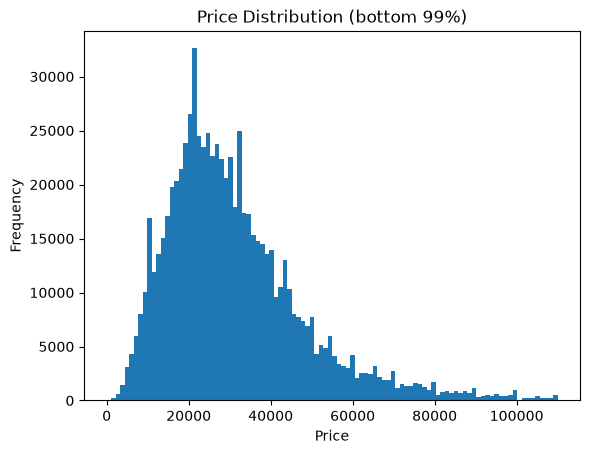

In [10]:
ax = df.loc[df["price"] <= p99, "price"].plot(kind="hist", bins = 100)
ax.set_xlabel("Price")
ax.set_title("Price Distribution (bottom 99%)")

next I'll make a log version which I'll end up using for modeling


Text(0.5, 0, 'log10(price) 4 = $10k, 5 = $100k, 6 = $1M)')

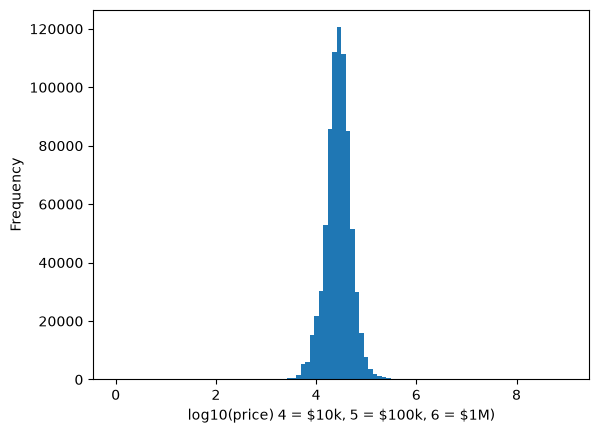

In [11]:
np.log10(df["price"]).plot(kind="hist", bins=100)
plt.xlabel("log10(price) 4 = $10k, 5 = $100k, 6 = $1M)")

In [12]:
counts = df.groupby(["manufacturer", "model"]).size().sort_values(ascending=False)
top20 = counts.head(20).reset_index(name="listings")
top20

,manufacturer,model,listings
0,Ford,Fusion SE,3172
1,Kia,Sportage LX,2873
2,Toyota,Corolla LE,2836
3,Mercedes-Benz,GLC 300 Base 4MATIC,2718
4,Nissan,Sentra SV,2652
5,Kia,Optima LX,2650
6,Ford,Explorer XLT,2542
7,Nissan,Rogue SV,2526
8,Toyota,Tundra SR5,2471
9,Kia,Sorento LX,2461


## Missing Values

now I will check what percent of each column is missing info to see if any of the columns are worth dropping.

In [13]:
missing = df.isna().mean().sort_values(ascending=False) * 100
missing.round(1)

price_drop             46.2
seller_rating          28.1
mpg                    18.6
interior_color          7.5
driver_rating           4.2
one_owner               4.1
personal_use_only       3.3
accidents_or_damage     3.2
fuel_type               3.0
drivetrain              2.8
engine                  2.0
transmission            1.3
exterior_color          1.2
seller_name             1.1
mileage                 0.1
manufacturer            0.0
year                    0.0
model                   0.0
driver_reviews_num      0.0
price                   0.0
dtype: float64

In [14]:
for col in ["price_drop", "mpg", "seller_rating", "accidents_or_damage", "one_owner"]:
    print(df[col].value_counts(dropna=False).head(8), "\n")

price_drop
NaN       351979
1000.0     54185
500.0      36629
200.0      15915
100.0      14721
2000.0     13255
300.0      11275
400.0      10318
Name: count, dtype: int64 

mpg
NaN      142071
19-26     16210
18-25     15751
17-25     14304
20-27     13546
16-23     11489
19-28     11242
21-28     10517
Name: count, dtype: int64 

seller_rating
NaN    213973
4.8     64396
4.7     56343
4.9     51092
4.6     49169
4.5     40523
4.4     30633
4.3     26375
Name: count, dtype: int64 

accidents_or_damage
0.0    569188
1.0    168691
NaN     24212
Name: count, dtype: int64 

one_owner
1.0    410579
0.0    320029
NaN     31483
Name: count, dtype: int64 



Nothing too important is missing a lot of information. 

Since missing info in price drop likely means the price never changed, i will make those 0. 

For  seller rating It looks like the seller just didn't get rated for sales so I can add a flag to it and just fill with the median so the model can learn if unrated sellers price differently

For MPG the same make/model/year should  have the same mpg so I can just fill in from the groups median.

fuel type, drivetrain, engine, transmission, I will map them to simplify the different types, and if needed ill fill with the most common value for the make/model/year

driver_rating ill fill with model median

accident_or_dmg, one_owner, personal_use_only, I am going to assume missing values just means unknown, and not no since that does affect the price

same with interior_color and exterior_color

and I will just drop the missing mileage rows since ther are so few in the data set, and filling it will just add noise

Update: seller and driver ratings were left as NaN rather than filled. See 02_clean for the reasoning.

## Mileage and year

In [15]:
df[["mileage", "year"]].describe()

,mileage,year
count,7.615850e+05,762091.000000
mean,5.578169e+04,2017.791398
std,4.355788e+04,5.110532
min,0.000000e+00,1915.000000
25%,2.328700e+04,2016.000000
50%,4.559600e+04,2019.000000
75%,7.836500e+04,2021.000000
max,1.119067e+06,2024.000000


max mileage is 1.1 million, which seems a little high so we will look into that, and min year is 1915 which is very low but still possible for example an off sale of a Ford Model T, so we will look deeper into that.

<Axes: xlabel='year'>

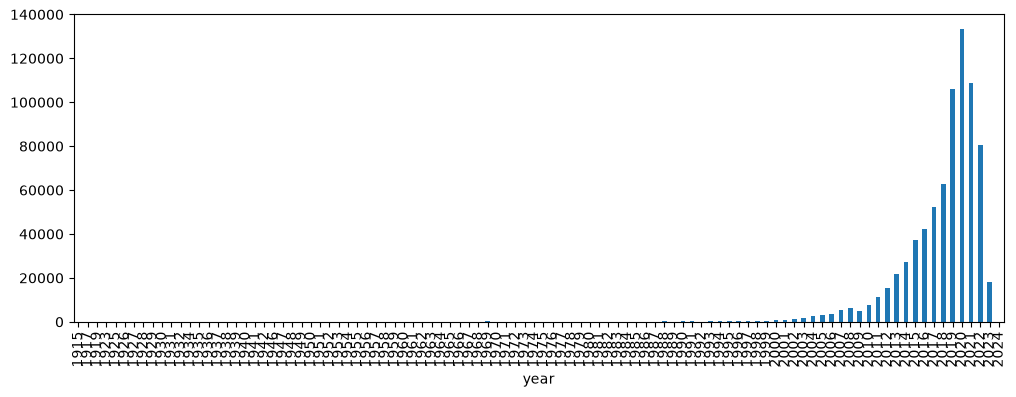

In [16]:
df["year"].value_counts().sort_index().plot(kind="bar", figsize=(12,4))

In [17]:
df.loc[df['year'] <= 1925]

,manufacturer,model,year,mileage,engine,transmission,drivetrain,fuel_type,mpg,exterior_color,interior_color,accidents_or_damage,one_owner,personal_use_only,seller_name,seller_rating,driver_rating,driver_reviews_num,price_drop,price
77047,Buick,Model H Base,1919,10240.0,6 Cyclinder,3 Speed Manual,NaN,NaN,0-0,Black,Black,0.0,NaN,1.0,Gateway Classic Cars,NaN,NaN,0.0,NaN,76000.0
152382,Chevrolet,Superior,1925,59593.0,I4,Manual,NaN,Gasoline,NaN,Blue Black,Blue,0.0,NaN,1.0,GR Auto Gallery,3.2,NaN,0.0,1000.0,17900.0
269779,Ford,Model T T-Bucket Roadster,1923,1698.0,V8 Supercharged,Automatic,NaN,Gasoline,NaN,Purple,Tan,0.0,NaN,1.0,KD's Auto Sales,2.6,3.4,2.0,NaN,45000.0
269781,Ford,Model T DOCTOR'S,1925,1.0,NaN,Manual,Rear-wheel Drive,NaN,NaN,Black,Gray,0.0,NaN,NaN,Anchor Auto Outlet,4.0,NaN,0.0,1000.0,14995.0
269783,Ford,Model T Runabout,1917,0.0,177 CC I4,Manual,NaN,NaN,0-0,Black,Black,0.0,NaN,NaN,Gateway Classic Cars,NaN,NaN,0.0,NaN,22500.0
269785,Ford,Model T Touring,1915,0.0,I4,2 Speed Ruckstell Rear Axle Manual,NaN,NaN,0-0,Black,Black,0.0,NaN,1.0,Gateway Classic Cars,NaN,NaN,0.0,NaN,33000.0
269787,Ford,Model T,1923,0.0,0 SELECT,Manual,NaN,NaN,NaN,Black,Black,0.0,NaN,1.0,Rise V West,4.2,3.4,2.0,NaN,24995.0
269788,Ford,Model T,1923,100.0,NaN,Manual,NaN,NaN,0-0,Black,Black,0.0,NaN,1.0,L.R.A. Enterprises,3.6,3.4,2.0,NaN,13900.0
269790,Ford,Model T,1923,14048.0,5.7L V8,Automatic,NaN,Gasoline,NaN,Blue / White,White,0.0,NaN,NaN,GR Auto Gallery,3.0,3.4,2.0,4000.0,29900.0
269791,Ford,Model T,1915,0.0,177 CID Inline 4 cylinder,2 Speed Manual,NaN,NaN,0-0,White,Black,0.0,NaN,1.0,Gateway Classic Cars,NaN,NaN,0.0,NaN,26000.0


Looks like that was the case, these are not errors, the cars sold are just old eventually we will see how  much these affect the model.

## Text/Category columns

In [18]:
for col in df.select_dtypes("str").columns:
    print(col, df[col].nunique())
    print(df[col].value_counts().head(10), "\n")

manufacturer 30
manufacturer
Ford             79526
Toyota           59535
Chevrolet        56043
Nissan           48529
Jeep             41665
Mercedes-Benz    40824
Honda            37612
BMW              37570
Kia              35063
GMC              29563
Name: count, dtype: int64 

model 12187
model
Fusion SE              3172
Sportage LX            2873
Corolla LE             2836
GLC 300 Base 4MATIC    2718
Sentra SV              2652
Optima LX              2650
Explorer XLT           2542
Rogue SV               2526
Tundra SR5             2471
Sorento LX             2461
Name: count, dtype: int64 

engine 6903
engine
2.0L I4 16V GDI DOHC Turbo    75545
3.6L V6 24V MPFI DOHC         35437
3.6L V6 24V GDI DOHC          27020
2.0L I4 16V MPFI DOHC         19534
1.5L I4 16V GDI DOHC Turbo    18173
3.5L V6 24V MPFI DOHC         17326
2.4L I4 16V GDI DOHC          17255
3.5L V6 24V PDI DOHC          15328
Electric                      14644
2.5L I4 16V GDI DOHC          13763
Name: co

## How many of each make/model are there

In [19]:
counts = df.groupby(["manufacturer", "model"]).size().sort_values(ascending=False)
counts.head(20)

manufacturer   model              
Ford           Fusion SE              3172
Kia            Sportage LX            2873
Toyota         Corolla LE             2836
Mercedes-Benz  GLC 300 Base 4MATIC    2718
Nissan         Sentra SV              2652
Kia            Optima LX              2650
Ford           Explorer XLT           2542
Nissan         Rogue SV               2526
Toyota         Tundra SR5             2471
Kia            Sorento LX             2461
Honda          Odyssey EX-L           2391
Lexus          RX 350 Base            2385
Kia            Forte LXS              2377
Jeep           Wrangler Sport         2373
Ford           Focus SE               2353
               Edge SEL               2285
               F-150 XLT              2279
Jeep           Renegade Latitude      2232
Ford           Escape SE              2232
Buick          Encore Preferred       2139
dtype: int64

In [20]:
(counts >= 100).sum()

np.int64(1520)

## Relationships Between Important Features and Price

<Axes: xlabel='year', ylabel='price'>

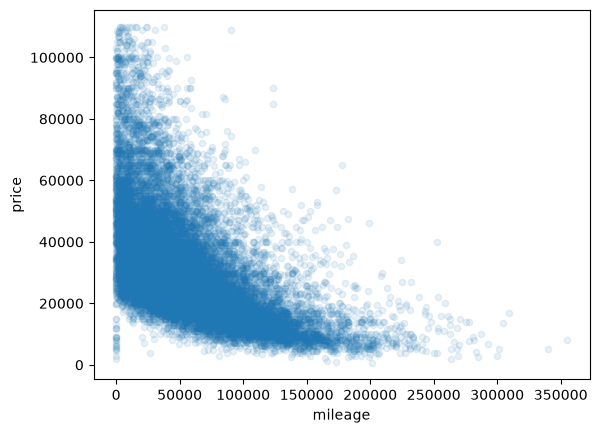

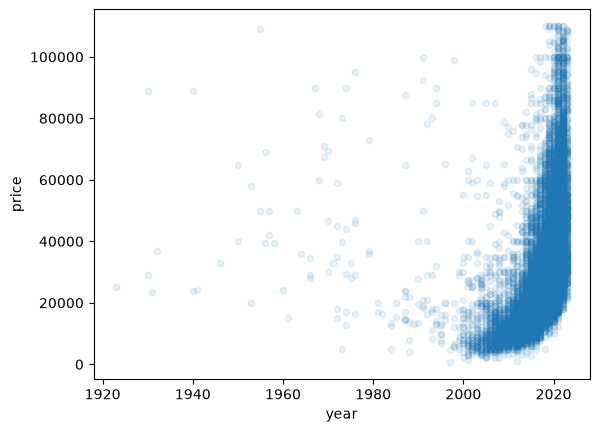

In [21]:
sample = df[df["price"] <= p99].sample(20000, random_state=42)
sample.plot.scatter(x="mileage", y="price", alpha=0.1)
sample.plot.scatter(x="year", y="price", alpha=0.1)

As expected the relationships between mileage and price are negative, and year and price and positive

In [22]:
cols = ["manufacturer", "model", "year", "mileage", "price"]
df.nlargest(25, "price")[cols]

,manufacturer,model,year,mileage,price
108142,Chevrolet,Cobalt LT,2009,85185.0,1.000000e+09
188113,Dodge,Durango Citadel,2018,113207.0,1.000000e+09
188260,Dodge,Durango Citadel,2018,113207.0,1.000000e+09
224571,Ford,Utility Police Interceptor Base,2016,NaN,8.888889e+06
84358,Cadillac,DeVille 77 HOURS ON ENGINES,1963,76.0,4.999999e+06
636956,RAM,ProMaster 3500 High Roof,2017,83000.0,3.490000e+06
613085,Porsche,Carrera GT,2005,780.0,2.250000e+06
609009,Porsche,918 Spyder Base (PDK),2015,2622.0,2.099995e+06
613080,Porsche,Carrera GT,2004,2361.0,1.899999e+06
49078,BMW,750 iL,1996,121043.0,1.750000e+06


In [23]:
df.nsmallest(25, "price")[cols]

,manufacturer,model,year,mileage,price
5658,Acura,TLX V6 A-Spec,2018,49603.0,1.0
13850,Audi,A4 2.0T Premium,2014,98881.0,1.0
660696,Subaru,Legacy 2.5i Limited,2019,31570.0,1.0
735177,Volkswagen,Jetta,2007,133964.0,1.0
584638,Nissan,Versa SV,2021,45288.0,259.0
195371,Ford,EcoSport Titanium,2019,44077.0,289.0
66049,Buick,Enclave Premium,2017,115869.0,299.0
73551,Buick,Encore Essence,2019,115608.0,299.0
599832,Nissan,Murano SV,2018,120524.0,299.0
600748,Nissan,Murano SV,2018,120524.0,299.0


In [24]:
for cap in [200_000, 500_000, 1_000_000]:
    print(f"> ${cap:,}:", (df["price"] > cap).sum())
for floor in [500, 1_000, 2_000]:
    print(f"< ${floor:,}:", (df["price"] < floor).sum())

> $200,000: 1399
> $500,000: 57
> $1,000,000: 28
< $500: 16
< $1,000: 39
< $2,000: 209


I am going to set the max to $200,000, and the minimum to $2,000 to avoid super cars, since they are too rare to be considered, and cars less than $2,000 since they are likely including values put in as placeholders for "call for price" or "down-payment"